Accuracy: 0.7037037037037037


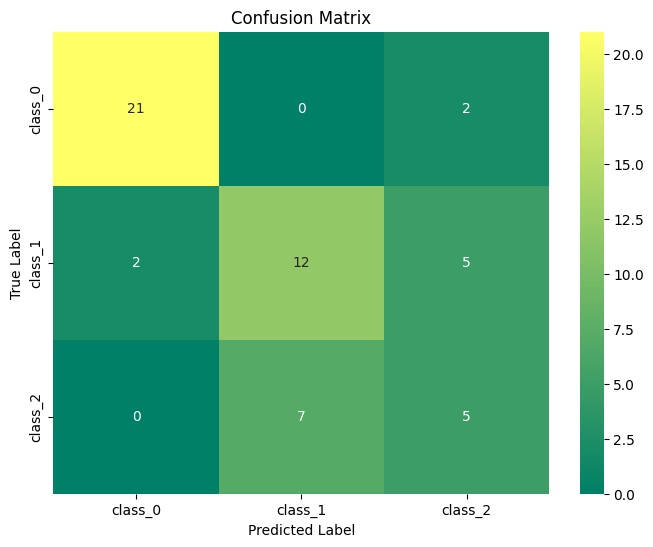

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

wine = load_wine()

data = pd.DataFrame(data=wine.data, columns=wine.feature_names)
data['Target'] = wine.target

x = data.drop('Target', axis=1)
y = data['Target']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='summer',
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()